<a href="https://colab.research.google.com/github/devpatel0005/Stock-Sentiment-Analysis-based-on-News/blob/main/Stock_Sentiment_Analysis_Using_LSTM_based_on_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU Setup for TensorFlow

This notebook is configured to use GPU acceleration with TensorFlow. After installing TensorFlow, restart the kernel to ensure GPU support is loaded. The code below checks for GPU availability and enables memory growth for efficient GPU usage.

In [1]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


In [38]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Embedding, Dropout, BatchNormalization, Bidirectional, LSTM,GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import one_hot
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

In [4]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tvard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tvard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

- The data set in consideration is a combination of the world news and stock price shifts available on Kaggle.
- There are 25 columns of top news headlines for each day in the data frame.
Data ranges from 2008 to 2016 and the data from 2000 to 2008 was scrapped from Yahoo finance.
- Labels are based on the Dow Jones Industrial Average stock index.
- Class 1 → the stock price increased.
- Class 0 → the stock price stayed the same or decreased.

In [5]:
import pandas as pd
df=pd.read_csv('Data.csv',encoding='ISO-8859-1')

df.sample(5)

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
1577,2006-06-19,1,South Korean fans do the dirty work in Leipzig,Magistrate hands in report on Italian corruption,Sweden's flying winger aims to give England th...,Nancy's Diary,Prospect of unleashing irrepressible Rooney ha...,Van der Vaart confident the Dutch will not argue,Pantsil accused of political naivety after fla...,"Klinsmann is right man for the future, says Ba...",...,World Cup in brief,Ukraine 4 - 0 Saudi Arabia,Digger: Reports of Owen premature,Eriksson promises the return of the short ball,Ecuador find their rhythm and confound their d...,David Pleat's chalkboard,"Jowell urges Fifa action to end scandal of £1,...",Fifa says no to goalline help,Henry hangs on to the memory as age takes its ...,Germany falls in behind Grinsi-Klinsi
879,2003-09-02,1,"'Forget cones, just let him bowl'",Moody commits himself to New Road,Williams driver in 160mph smash,Cooley's run-through,Sheahan free to play in World Cup,Dragons seek to breathe fire from discord,Spokesman reignites Springbok race row,Injury puts Kefu out of cup,...,Invisible man takes wraps off England's pacemen,Stewart argues case for oldies,Keane hopes Swiss timing is right,Newcastle riled by Bellamy call-up,Mayhem Macedonian style,Real 'hard up' claims Makelele,Sakiri happy with fruits of his corner,Makelele ends £111m spree,Lampard can sharpen diamond,Deadline day signings
1189,2004-11-24,1,Naybet fears worst,MP demands change in FA,An insider's guide to victory in Eindhoven by ...,Injured Larsson offered lifeline by Barça,PSV 1 Arsenal 1,Just say no,Just say no,Daily Star cites PR guru in contempt defence,...,"No ID cards, please, we're British",Berlin salutes British hero,Ballot printing error sets up Hull election rerun,"David Bowie, and Dan Dare",England put Zimbabwe tour on hold,Prescott hails Thames Gateway 'opportunity',Court gives green light to MyTravel restructuring,The world is Sensible again,"Max Hastings: For Blunkett, every day is a Dan...",Unqualified success
2435,2009-11-18,0,b'CAUGHT: Guy who dropped dog from a bridge in...,b'The official inductees of the 2010 Sweatshop...,b'Van Rompuy is the first president of Europe',b'Russia confirms death penalty ban',b'Dont ask: A new law against homosexuality in...,"b""For the first time, Africa's population exce...",b'An open letter to Obama from a Gaza resident...,b'The Tijuana of the Caspian - Where Iranians ...,...,"b'""There are stupid women who come to the West...",b'Suicide bomber in Pakistan kills 19 at court...,b'State Department says Israel discriminates',b'Russian court extends moratorium on death pe...,b'Abbas: Only solution is to declare Palestini...,"b'Van Rompuy takes EU presidency, Lady Ashton ...",b'Big Oil and Big Coal Spend Big to Kill Clean...,"b""Indonesian Elementary School Students Set Fi...",b'Lions kill white tiger in Czech zoo',"b'Poland, Lithuania and Ukraine to set up ""joi..."
563,2002-04-15,1,Continent has winning look,Gregory chases comeback with Swinton,Saracens dealt Bracken blow,France hails 15-year-old as Safin eyes clay crown,Carbury at short odds for National,US Masters final scoreboard,Radcliffe may need operation on knee,Byas looks to life on t'other side,...,"Joan Rivers, London","David Mead, Manchester","Northern Sinfonia, Newcastle",Tall order for Taylor to fit Crouch with wings,Women's football,Round up,Tigers call up cavalry to fix their fourth title,Late call for Keown after Cup injuries,Brown still in the frame,England squad v Paraguay


- ISO-8859-1, also known as Latin-1, is a character encoding standard that maps 256 different characters to numerical values. It's one of the most common encodings used for text in Western European languages

In [6]:
df.shape

(4101, 27)

# Splitting the Data into train and test

In [7]:
df['Date']

0       2000-01-03
1       2000-01-04
2       2000-01-05
3       2000-01-06
4       2000-01-07
           ...    
4096    2016-06-27
4097    2016-06-28
4098    2016-06-29
4099    2016-06-30
4100    2016-07-01
Name: Date, Length: 4101, dtype: object

In [8]:
train=df[df['Date']<'20150101']
test=df[df['Date']>'20141231']

In [9]:
test.shape

(378, 27)

In [10]:
train.shape

(3975, 27)

# Feature Engineering


In [11]:
data=train.iloc[:,2:27]
data.replace('[^a-zA-Z]',' ',regex=True,inplace=True) #replace the full stop punctuattion with space

#renaming the columns for ease of acess
new_index=[str(i) for i in range(25)] #since our data has 25 columns top 25 news headlines for stock
data.columns=new_index

In [12]:
data

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A hindrance to operations extracts from the...,Scorecard,Hughes instant hit buoys Blues,Jack gets his skates on at ice cold Alex,Chaos as Maracana builds up for United,Depleted Leicester prevail as Elliott spoils E...,Hungry Spurs sense rich pickings,Gunners so wide of an easy target,Derby raise a glass to Strupar s debut double,Southgate strikes Leeds pay the penalty,...,Flintoff injury piles on woe for England,Hunters threaten Jospin with new battle of the...,Kohl s successor drawn into scandal,The difference between men and women,Sara Denver nurse turned solicitor,Diana s landmine crusade put Tories in a panic,Yeltsin s resignation caught opposition flat f...,Russian roulette,Sold out,Recovering a title
1,Scorecard,The best lake scene,Leader German sleaze inquiry,Cheerio boyo,The main recommendations,Has Cubie killed fees,Has Cubie killed fees,Has Cubie killed fees,Hopkins furious at Foster s lack of Hannibal...,Has Cubie killed fees,...,On the critical list,The timing of their lives,Dear doctor,Irish court halts IRA man s extradition to Nor...,Burundi peace initiative fades after rebels re...,PE points the way forward to the ECB,Campaigners keep up pressure on Nazi war crime...,Jane Ratcliffe,Yet more things you wouldn t know without the ...,Millennium bug fails to bite
2,Coventry caught on counter by Flo,United s rivals on the road to Rio,Thatcher issues defence before trial by video,Police help Smith lay down the law at Everton,Tale of Trautmann bears two more retellings,England on the rack,Pakistan retaliate with call for video of Walsh,Cullinan continues his Cape monopoly,McGrath puts India out of their misery,Blair Witch bandwagon rolls on,...,South Melbourne Australia,Necaxa Mexico,Real Madrid Spain,Raja Casablanca Morocco,Corinthians Brazil,Tony s pet project,Al Nassr Saudi Arabia,Ideal Holmes show,Pinochet leaves hospital after tests,Useful links
3,Pilgrim knows how to progress,Thatcher facing ban,McIlroy calls for Irish fighting spirit,Leicester bin stadium blueprint,United braced for Mexican wave,Auntie back in fashion even if the dress look...,Shoaib appeal goes to the top,Hussain hurt by shambles but lays blame on e...,England s decade of disasters,Revenge is sweet for jubilant Cronje,...,Putin admits Yeltsin quit to give him a head s...,BBC worst hit as digital TV begins to bite,How much can you pay for,Christmas glitches,Upending a table Chopping a line and Scoring ...,Scientific evidence unreliable defence claims,Fusco wins judicial review in extradition case,Rebels thwart Russian advance,Blair orders shake up of failing NHS,Lessons of law s hard heart
4,Hitches and Horlocks,Beckham off but United survive,Breast cancer screening,Alan Parker,Guardian readers are you all whingers,Hollywood Beyond,Ashes and diamonds,Whingers a formidable minority,Alan Parker part two,Thuggery Toxins and Ties,...,Most everywhere UDIs,Most wanted Chloe lunettes,Return of the cane completely off the agenda,From Sleepy Hollow to Greeneland,Blunkett outlines vision for over s,Embattled Dobson attacks play now pay later ...,Doom and the Dome,What is the north south divide,Aitken released from jail,Gone aloft
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970,Brazil declares emergency after babies a...,Scientists find big yr old Viking settlem...,Paris attacks Belgian police arrest ninth sus...,Wiretapping reveals communication between Turk...,Russia airstrikes Hundreds of Syrian civilans...,Pakistan changes neutral position on Syrian Ci...,North Korean diplomat arrested in South Africa...,German teachers want Mein Kampf on syllabus,North Korea slave force earns Kim Jong Un regi...,Yemeni Forces Preparing to Attack Saudi...,...,Report on sexual exploitation and abuse by pea...,Baby girl dies after X president s son s staff...,China smog sparks red alerts in cities,US planned East Berlin s systematic destructi...,Qatar World Cup workers e

# Converting the headlines into lowercase

In [13]:
for index in new_index:
  data[index]=data[index].str.lower()

In [14]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,a hindrance to operations extracts from the...,scorecard,hughes instant hit buoys blues,jack gets his skates on at ice cold alex,chaos as maracana builds up for united,depleted leicester prevail as elliott spoils e...,hungry spurs sense rich pickings,gunners so wide of an easy target,derby raise a glass to strupar s debut double,southgate strikes leeds pay the penalty,...,flintoff injury piles on woe for england,hunters threaten jospin with new battle of the...,kohl s successor drawn into scandal,the difference between men and women,sara denver nurse turned solicitor,diana s landmine crusade put tories in a panic,yeltsin s resignation caught opposition flat f...,russian roulette,sold out,recovering a title
1,scorecard,the best lake scene,leader german sleaze inquiry,cheerio boyo,the main recommendations,has cubie killed fees,has cubie killed fees,has cubie killed fees,hopkins furious at foster s lack of hannibal...,has cubie killed fees,...,on the critical list,the timing of their lives,dear doctor,irish court halts ira man s extradition to nor...,burundi peace initiative fades after rebels re...,pe points the way forward to the ecb,campaigners keep up pressure on nazi war crime...,jane ratcliffe,yet more things you wouldn t know without the ...,millennium bug fails to bite
2,coventry caught on counter by flo,united s rivals on the road to rio,thatcher issues defence before trial by video,police help smith lay down the law at everton,tale of trautmann bears two more retellings,england on the rack,pakistan retaliate with call for video of walsh,cullinan continues his cape monopoly,mcgrath puts india out of their misery,blair witch bandwagon rolls on,...,south melbourne australia,necaxa mexico,real madrid spain,raja casablanca morocco,corinthians brazil,tony s pet project,al nassr saudi arabia,ideal holmes show,pinochet leaves hospital after tests,useful links
3,pilgrim knows how to progress,thatcher facing ban,mcilroy calls for irish fighting spirit,leicester bin stadium blueprint,united braced for mexican wave,auntie back in fashion even if the dress look...,shoaib appeal goes to the top,hussain hurt by shambles but lays blame on e...,england s decade of disasters,revenge is sweet for jubilant cronje,...,putin admits yeltsin quit to give him a head s...,bbc worst hit as digital tv begins to bite,how much can you pay for,christmas glitches,upending a table chopping a line and scoring ...,scientific evidence unreliable defence claims,fusco wins judicial review in extradition case,rebels thwart russian advance,blair orders shake up of failing nhs,lessons of law s hard heart
4,hitches and horlocks,beckham off but united survive,breast cancer screening,alan parker,guardian readers are you all whingers,hollywood beyond,ashes and diamonds,whingers a formidable minority,alan parker part two,thuggery toxins and ties,...,most everywhere udis,most wanted chloe lunettes,return of the cane completely off the agenda,from sleepy hollow to greeneland,blunkett outlines vision for over s,embattled dobson attacks play now pay later ...,doom and the dome,what is the north south divide,aitken released from jail,gone aloft


- Now for implementing the NLP techniques like Bag of Words or Tf-IDF we need to combine these all columns of a row into one single paragraph for every row

In [15]:
data.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974],
      dtype='int64', length=3975)

In [16]:
headlines=[]
for rows in range(0,len(data.index)):
  headlines.append(' '.join(str(x) for x in data.iloc[rows,0:25])) # columns are from 0 to 24 so we mentioned 0:25 to include all

In [17]:
headlines[1]

'scorecard the best lake scene leader  german sleaze inquiry cheerio  boyo the main recommendations has cubie killed fees  has cubie killed fees  has cubie killed fees  hopkins  furious  at foster s lack of hannibal appetite has cubie killed fees  a tale of two tails i say what i like and i like what i say elbows  eyes and nipples task force to assess risk of asteroid collision how i found myself at last on the critical list the timing of their lives dear doctor irish court halts ira man s extradition to northern ireland burundi peace initiative fades after rebels reject mandela as mediator pe points the way forward to the ecb campaigners keep up pressure on nazi war crimes suspect jane ratcliffe yet more things you wouldn t know without the movies millennium bug fails to bite'

- Now for every row we have merged  of each and every index the news into one single headline

In [18]:
ps=PorterStemmer()

In [19]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

ps = PorterStemmer()

stop_words = set(stopwords.words('english'))  # load once

stem_headlines = []

for paragraph in headlines:
    processed_paragraph_words = []
    sentences = nltk.sent_tokenize(paragraph)

    for sentence in sentences:
        words_in_sentence = nltk.word_tokenize(sentence)

        for word in words_in_sentence:
            word_lower = word.lower()

            if word_lower not in stop_words:
                processed_paragraph_words.append(ps.stem(word_lower))

    stem_headlines.append(' '.join(processed_paragraph_words))


In [21]:
all_words = set()
for headline in stem_headlines:
  for word in headline.split():
    all_words.add(word)
voc_size = len(all_words) + 1

print(f"Calculated vocabulary size: {voc_size}")

Calculated vocabulary size: 31838


In [22]:
onehot_repr = [one_hot(words, voc_size) for words in stem_headlines]
print(f"First one-hot encoded headline: {onehot_repr[0]}")

First one-hot encoded headline: [27471, 17491, 10901, 7115, 5777, 9357, 20320, 15523, 1226, 14212, 6696, 31043, 5248, 28877, 26043, 2659, 27669, 9627, 13007, 25124, 17205, 4737, 24946, 18973, 3631, 31506, 3195, 20034, 25755, 23736, 19205, 508, 7134, 28968, 769, 13592, 9397, 31778, 21413, 29030, 22702, 4998, 5137, 29001, 716, 18069, 24801, 13172, 27401, 5926, 18672, 26411, 5935, 23019, 20034, 21075, 12494, 12397, 2757, 13762, 14696, 27853, 17449, 3949, 25970, 11255, 3921, 26874, 1226, 25291, 12427, 20839, 15834, 15078, 18127, 8630, 10444, 7454, 5852, 31358, 30730, 18496, 28477, 25943, 8670, 22618, 23235, 3696, 10648, 20933, 2757, 25937, 1630, 24368, 10028, 8035, 467, 15340, 15977, 12822, 31172, 15502, 26646, 13782, 30581, 29994, 27915, 16357, 26112]


In [23]:
maxlen = max([len(x) for x in onehot_repr])
print(f"Maximum length of a headline for padding: {maxlen}")

Maximum length of a headline for padding: 479


In [24]:
embedded_docs = pad_sequences(onehot_repr, padding='pre', maxlen=maxlen)
print(f"Shape of embedded documents after padding: {embedded_docs.shape}")

Shape of embedded documents after padding: (3975, 479)


In [25]:
import numpy as np
y_train = np.array(train['Label'])

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train_split, y_val = train_test_split(embedded_docs, y_train, test_size=0.2, random_state=42)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_val: {x_val.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of x_train: (3180, 479)
Shape of x_val: (795, 479)
Shape of y_train_split: (3180,)
Shape of y_val: (795,)


In [66]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,Dropout,BatchNormalization,LSTM, Input, Reshape, Bidirectional # Added Bidirectional
from tensorflow.keras.regularizers import l2 # Import l2 regularizer


EMBEDDING_DIM = 50  # smaller embedding to limit capacity

model = Sequential()
model.add(Embedding(input_dim=voc_size, output_dim=EMBEDDING_DIM))
# first bidirectional GRU with strong regularization
model.add(Bidirectional(GRU(64,return_sequences=True, kernel_regularizer=l2(0.01))))
model.add(Dropout(0.4))
# optional second GRU to see if stacking helps (keep relatively small)
model.add(Bidirectional(GRU(32, kernel_regularizer=l2(0.01))))
model.add(Dropout(0.4))
# reduced-capacity output layer with regularizer
model.add(Dense(1, activation='sigmoid', dtype='float32', kernel_regularizer=l2(0.01)))

model.summary()


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, None, 50)          1591900   
                                                                 
 bidirectional_10 (Bidirecti  (None, None, 128)        44544     
 onal)                                                           
                                                                 
 dropout_9 (Dropout)         (None, None, 128)         0         
                                                                 
 bidirectional_11 (Bidirecti  (None, 64)               31104     
 onal)                                                           
                                                                 
 dropout_10 (Dropout)        (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 1)                

In [67]:
from tensorflow.keras.optimizers import Adam

# Use loss scaling for mixed precision training and a lower lr
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

In [68]:
x_train.shape, y_train_split.shape, x_val.shape, y_val.shape

((3180, 479), (3180,), (795, 479), (795,))

In [70]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
ckpt  = ModelCheckpoint('best.h5', save_best_only=True)

history = model.fit(
    x_train, y_train_split,
    epochs=50,               # raise epochs, let early stopping cut it
    batch_size=64,
    validation_split=0.1,
    callbacks=[early, ckpt],
    verbose=1
)

Epoch 1/50
45/45 [==============================] - 7s 115ms/step - loss: 2.0803 - accuracy: 0.5762 - val_loss: 2.0178 - val_accuracy: 0.5503
Epoch 2/50
45/45 [==============================] - 5s 108ms/step - loss: 1.9532 - accuracy: 0.5294 - val_loss: 1.8985 - val_accuracy: 0.5503
Epoch 3/50
45/45 [==============================] - 5s 109ms/step - loss: 1.8251 - accuracy: 0.5769 - val_loss: 1.8012 - val_accuracy: 0.4748
Epoch 4/50
45/45 [==============================] - 5s 107ms/step - loss: 1.6424 - accuracy: 0.7603 - val_loss: 1.7458 - val_accuracy: 0.4528
Epoch 5/50
45/45 [==============================] - 5s 104ms/step - loss: 1.3841 - accuracy: 0.8599 - val_loss: 1.7697 - val_accuracy: 0.4748
Epoch 6/50
45/45 [==============================] - 5s 102ms/step - loss: 1.1601 - accuracy: 0.9210 - val_loss: 1.8127 - val_accuracy: 0.5000
Epoch 7/50
45/45 [==============================] - 5s 112ms/step - loss: 0.9837 - accuracy: 0.9654 - val_loss: 1.8622 - val_accuracy: 0.4937


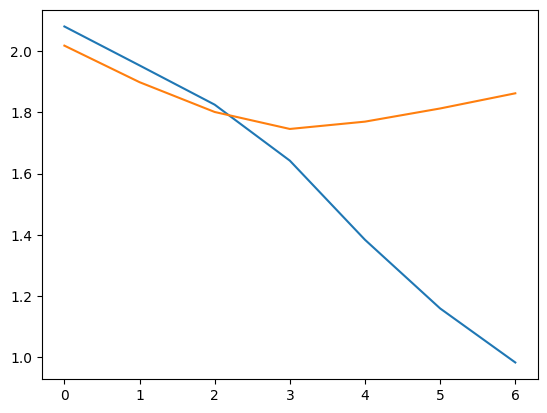

In [71]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the training data
y_pred_train_proba = model.predict(x_train)
y_pred_train = (y_pred_train_proba > 0.5).astype(int)

# Generate classification report for training data
print("\nTraining Classification Report:")
print(classification_report(y_train_split, y_pred_train))

100/100 [==============================] - 4s 39ms/step

Training Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1495
           1       0.95      0.95      0.95      1685

    accuracy                           0.95      3180
   macro avg       0.95      0.95      0.95      3180
weighted avg       0.95      0.95      0.95      3180



In [72]:
# evaluate on the untouched test set
y_test = np.array(test['Label'])
y_pred_test = (model.predict(pad_sequences(
                    [one_hot(' '.join(str(x) for x in row), voc_size)
                     for row in test.iloc[:,2:27].values],
                    padding='pre', maxlen=maxlen
                )) > 0.5).astype(int)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

12/12 [==============================] - 1s 45ms/step
Test accuracy: 0.5740740740740741
              precision    recall  f1-score   support

           0       0.70      0.23      0.35       186
           1       0.55      0.91      0.68       192

    accuracy                           0.57       378
   macro avg       0.63      0.57      0.52       378
weighted avg       0.63      0.57      0.52       378

